# PB-11: Evaluación de Modelos de Clasificación

En este notebook se evalúan los modelos baseline entrenados previamente (PB-10) utilizando diferentes métricas de desempeño y validación cruzada, con el objetivo de comparar su rendimiento y seleccionar los mejores candidatos.

Para evaluar los modelos se utilizan las siguientes métricas:

- Accuracy: proporción de predicciones correctas.
- Precision: proporción de positivos predichos que son correctos.
- Recall: proporción de positivos reales detectados.
- F1-score: balance entre precision y recall.
- AUC-ROC: capacidad del modelo para discriminar entre clases.


=== Cross-validation para LogisticRegression ===
{'accuracy': np.float64(0.8012666666666666), 'precision': np.float64(0.6189509731143883), 'recall': np.float64(0.2647683423974723), 'f1': np.float64(0.37082085764577905), 'roc_auc': np.float64(0.7430070205296395)}

=== Cross-validation para DecisionTree ===
{'accuracy': np.float64(0.7234666666666667), 'precision': np.float64(0.3812018381755591), 'recall': np.float64(0.40159318509910025), 'f1': np.float64(0.391056129638626), 'roc_auc': np.float64(0.6089850243385099)}

=== Cross-validation para RandomForest ===
{'accuracy': np.float64(0.8141333333333334), 'precision': np.float64(0.6375567066487644), 'recall': np.float64(0.37040259757946636), 'f1': np.float64(0.4685593247704688), 'roc_auc': np.float64(0.7628769988633959)}

=== Cross-validation para SVM ===
{'accuracy': np.float64(0.8169000000000001), 'precision': np.float64(0.6585435468007554), 'recall': np.float64(0.35804673100843465), 'f1': np.float64(0.4638433953642661), 'roc_auc': np.f

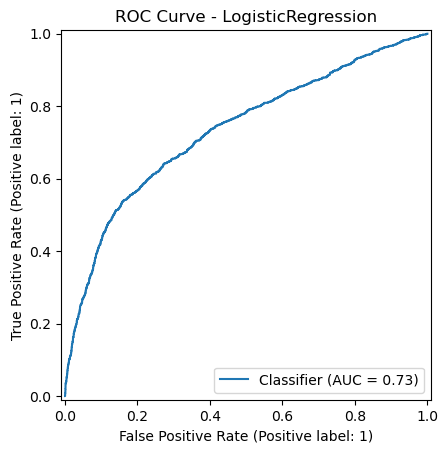

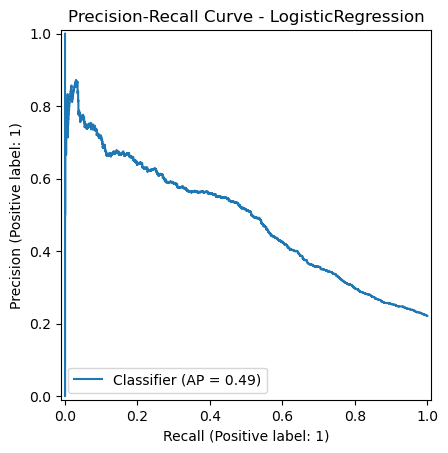


=== Reportes para DecisionTree ===

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.82      4673
           1       0.38      0.40      0.39      1327

    accuracy                           0.72      6000
   macro avg       0.60      0.61      0.60      6000
weighted avg       0.73      0.72      0.72      6000

Confusion Matrix:
[[3810  863]
 [ 802  525]]


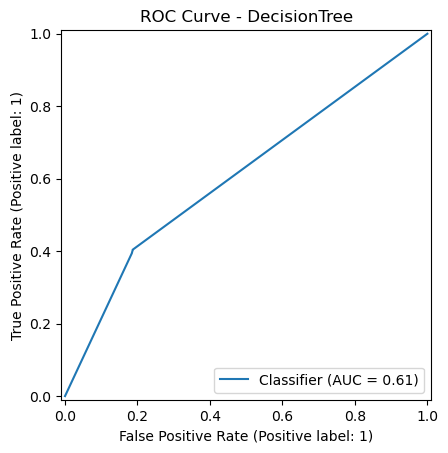

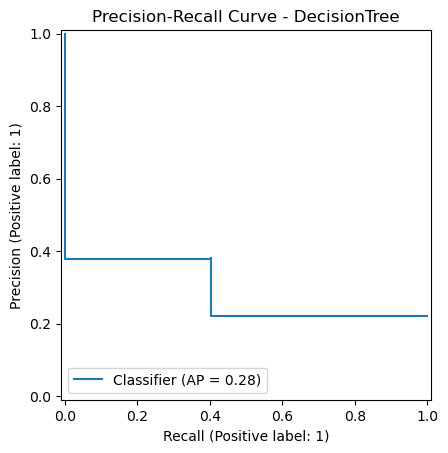


=== Reportes para RandomForest ===

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.88      4673
           1       0.61      0.35      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.72      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000

Confusion Matrix:
[[4379  294]
 [ 862  465]]


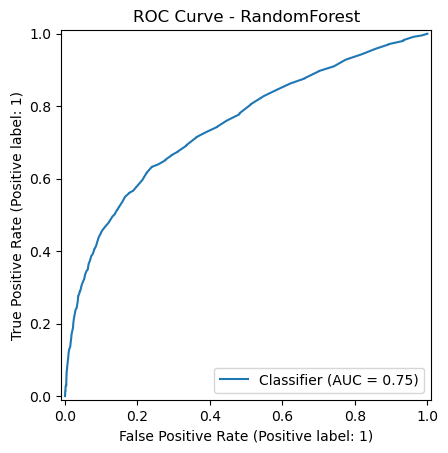

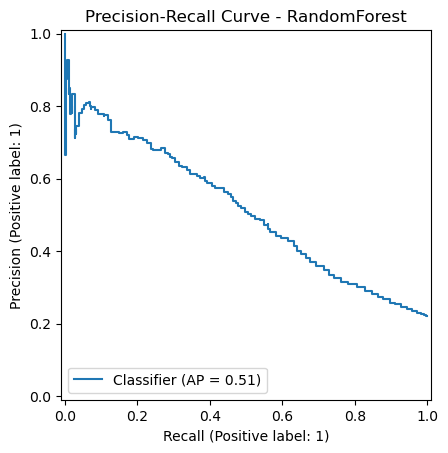


=== Reportes para SVM ===

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

Confusion Matrix:
[[4401  272]
 [ 853  474]]


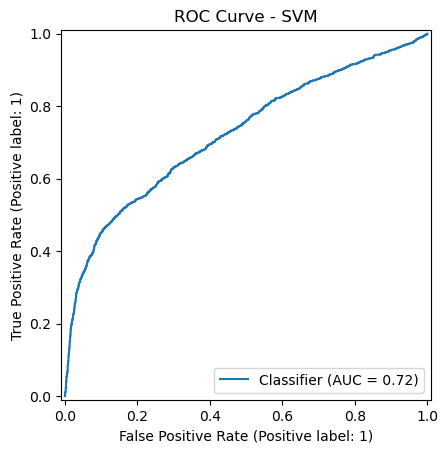

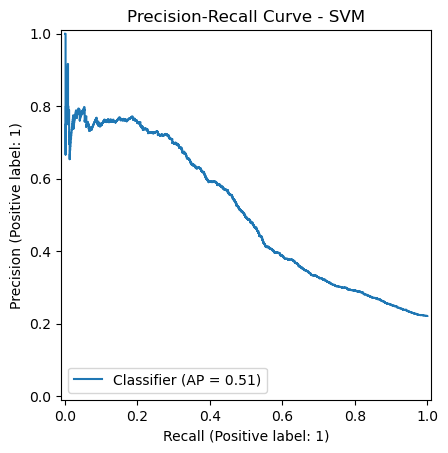


=== Reportes para KNN ===

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4673
           1       0.54      0.33      0.41      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.63      0.64      6000
weighted avg       0.77      0.79      0.77      6000

Confusion Matrix:
[[4302  371]
 [ 884  443]]


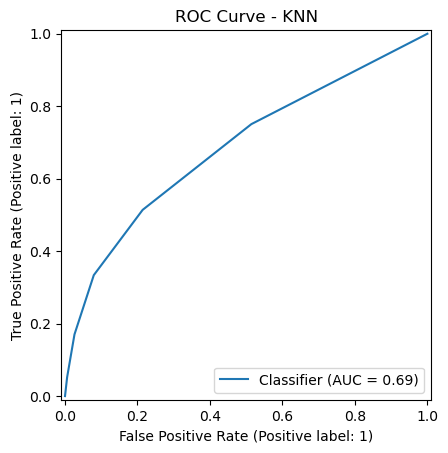

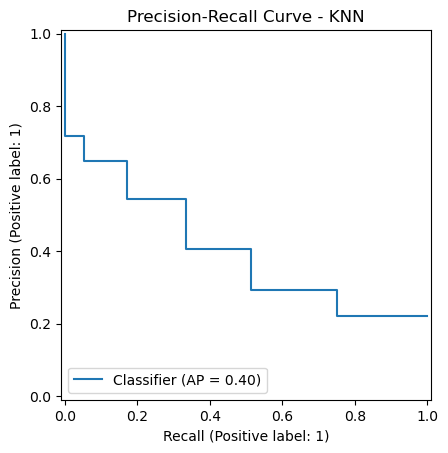

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Modelos baseline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# ============================================================
# 1. Cargar dataset procesado
# ============================================================
df = pd.read_csv("../data/processed/04_default_credit_features.csv")
df = df.drop(columns=["ID"])

TARGET = "default payment next month"
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Detectar columnas
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# ============================================================
# 2. Construir preprocesador
# ============================================================
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preproc = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

# ============================================================
# 3. Definir modelos baseline
# ============================================================
modelos = {
    "LogisticRegression": LogisticRegression(max_iter=5000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
}

# ============================================================
# 4. Cross-validation (5-fold stratified)
# Se aplica validación cruzada estratificada con 5 folds (StratifiedKFold) para obtener estimaciones robustas del desempeño de cada modelo.

# ============================================================
metricas = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nombre, modelo in modelos.items():
    print(f"\n=== Cross-validation para {nombre} ===")

    pipe = Pipeline([
        ("preprocessing", preproc),
        ("clf", modelo)
    ])

    scores = cross_validate(
        pipe, X, y, cv=cv, scoring=metricas
    )

    print({m: scores[f"test_{m}"].mean() for m in metricas})

# ============================================================
# 5. Train/Test split para reportes y curvas
# Se divide el dataset en entrenamiento (80%) y prueba (20%) para evaluar el desempeño final de los modelos en datos no vistos.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ============================================================
# 6. Reportes y curvas
# ============================================================
for nombre, modelo in modelos.items():
    print(f"\n=== Reportes para {nombre} ===")

    pipe = Pipeline([
        ("preprocessing", preproc),
        ("clf", modelo)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"ROC Curve - {nombre}")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_prob)
    plt.title(f"Precision-Recall Curve - {nombre}")
    plt.show()

# Métrica principal del proyecto

Dado que el problema consiste en predecir el incumplimiento de pago (default), la métrica más relevante es el recall de la clase positiva (default).

Esto se debe a que:

- Un falso negativo implica no detectar a un cliente que incumplirá.
- Esto representa una pérdida financiera para la entidad.

Por lo tanto, se prioriza maximizar el recall, aunque se mantenga un equilibrio con otras métricas como F1-score y AUC-ROC.
